In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

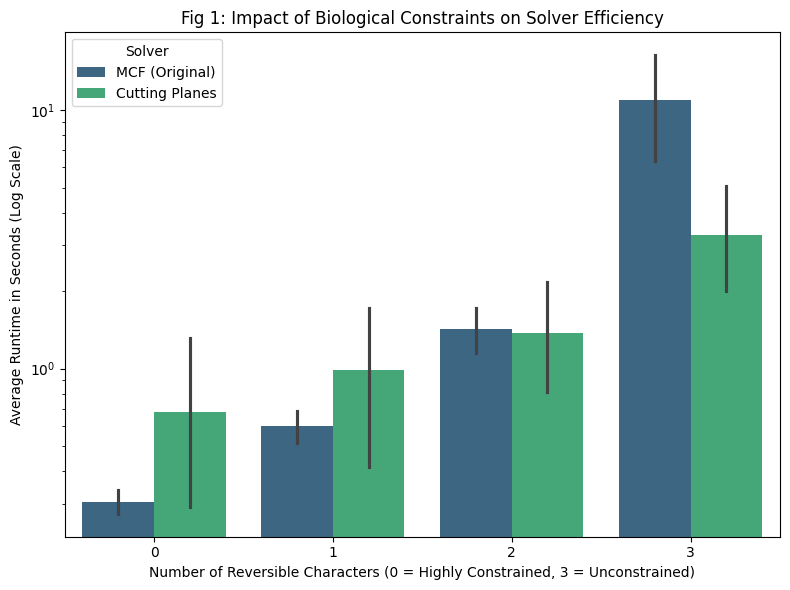

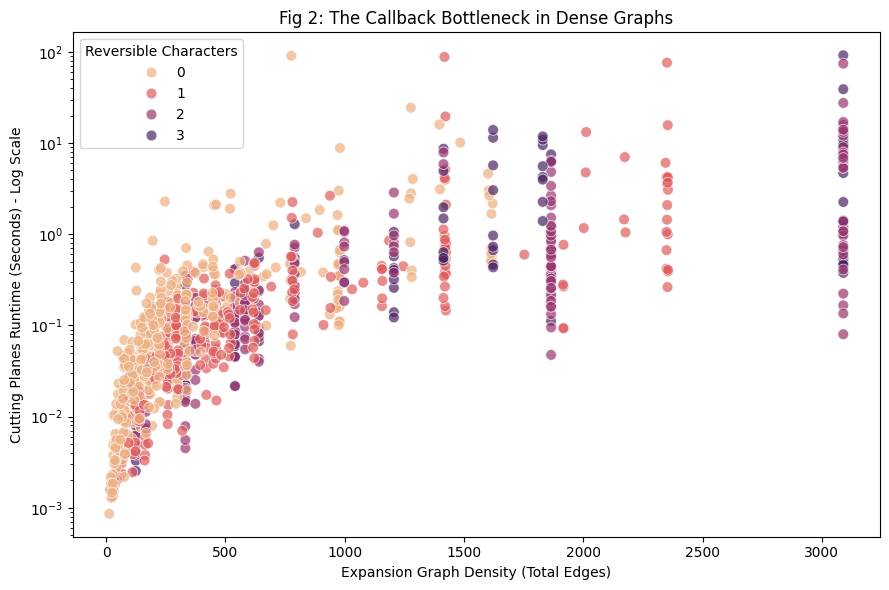

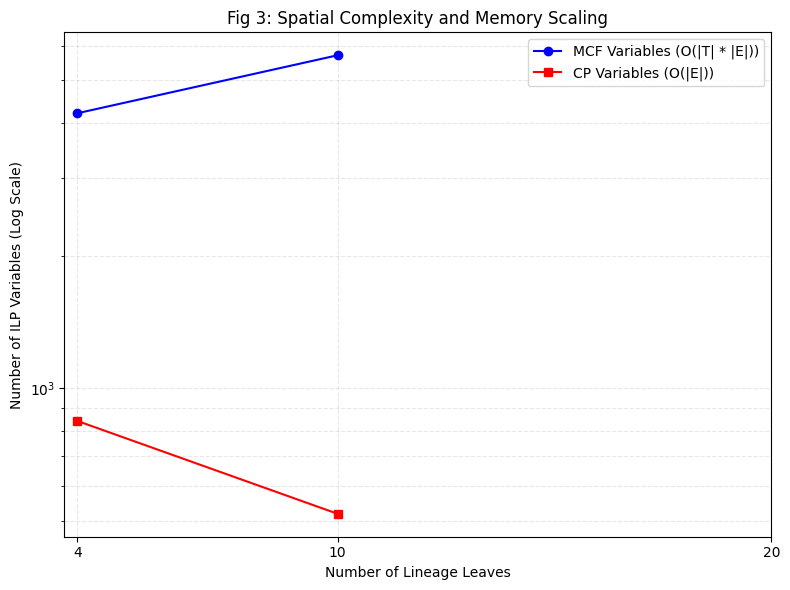

In [22]:
# ==========================================
# 1. LOAD AND PREP THE DATA
# ==========================================
df = pd.read_csv("results/benchmark_results_5_16_r3.csv")

# Split the ID to safely grab all three characters
id_parts = df['id'].str.split('_', expand=True)
df['char_1'] = id_parts[2]
df['char_2'] = id_parts[3]
df['char_3'] = id_parts[4]

# Count how many of the 3 characters are "reversible"
df['num_reversible'] = (
    (df['char_1'] == 'reversible').astype(int) + 
    (df['char_2'] == 'reversible').astype(int) + 
    (df['char_3'] == 'reversible').astype(int)
)

# Filter out failures/timeouts for accurate runtime plots
df_valid = df[df['score_match'] == True].copy()

# ==========================================
# FIGURE 1: The Topology Mix Impact
# ==========================================
plt.figure(figsize=(8, 6))
# Melt the dataframe so we can plot both MCF and CP times side-by-side
df_melted = df_valid.melt(
    id_vars=['num_reversible'], 
    value_vars=['time_original', 'time_cp'],
    var_name='Solver', 
    value_name='Runtime'
)

# Rename for clean plot labels
df_melted['Solver'] = df_melted['Solver'].map({'time_original': 'MCF (Original)', 'time_cp': 'Cutting Planes'})

sns.barplot(data=df_melted, x='num_reversible', y='Runtime', hue='Solver', palette='viridis')
plt.yscale('log')
plt.xlabel("Number of Reversible Characters (0 = Highly Constrained, 3 = Unconstrained)")
plt.ylabel("Average Runtime in Seconds (Log Scale)")
plt.title("Fig 1: Impact of Biological Constraints on Solver Efficiency")
plt.tight_layout()
plt.savefig("fig1_topology_impact.png", dpi=300)
plt.show()

# ==========================================
# FIGURE 2: The Density Bottleneck (Scatter)
# ==========================================
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_valid, 
    x='expansion_edges', 
    y='time_cp', 
    hue='num_reversible', 
    palette='flare',
    alpha=0.7,
    s=60 # dot size
)

plt.yscale('log')
plt.xlabel("Expansion Graph Density (Total Edges)")
plt.ylabel("Cutting Planes Runtime (Seconds) - Log Scale")
plt.title("Fig 2: The Callback Bottleneck in Dense Graphs")
plt.legend(title="Reversible Characters")
plt.tight_layout()
plt.savefig("fig2_density_bottleneck.png", dpi=300)
plt.show()

# ==========================================
# FIGURE 3: The Variable Explosion (Justification)
# ==========================================
# Calculate theoretical variable counts
# MCF = Binary Edges + (Continuous Flow Variables = Leaves * Edges)
df_valid['mcf_variables'] = df_valid['expansion_edges'] + (df_valid['n_leaves'] * df_valid['expansion_edges'])
# CP = Only Binary Edges
df_valid['cp_variables'] = df_valid['expansion_edges']

plt.figure(figsize=(8, 6))

# Group by the number of leaves to show how it scales
var_scaling = df_valid.groupby('n_leaves')[['mcf_variables', 'cp_variables']].mean().reset_index()

plt.plot(var_scaling['n_leaves'], var_scaling['mcf_variables'], marker='o', color='blue', label='MCF Variables (O(|T| * |E|))')
plt.plot(var_scaling['n_leaves'], var_scaling['cp_variables'], marker='s', color='red', label='CP Variables (O(|E|))')

plt.yscale('log')
plt.xticks([4, 10, 20]) # Assuming your leaves are 4, 10, and 20
plt.xlabel("Number of Lineage Leaves")
plt.ylabel("Number of ILP Variables (Log Scale)")
plt.title("Fig 3: Spatial Complexity and Memory Scaling")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig("fig3_variable_explosion.png", dpi=300)
plt.show()

/var/folders/tj/bppvsjh16m990_1bbwvc05r80000gn/T/ipykernel_84028/2268009901.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Algorithm")


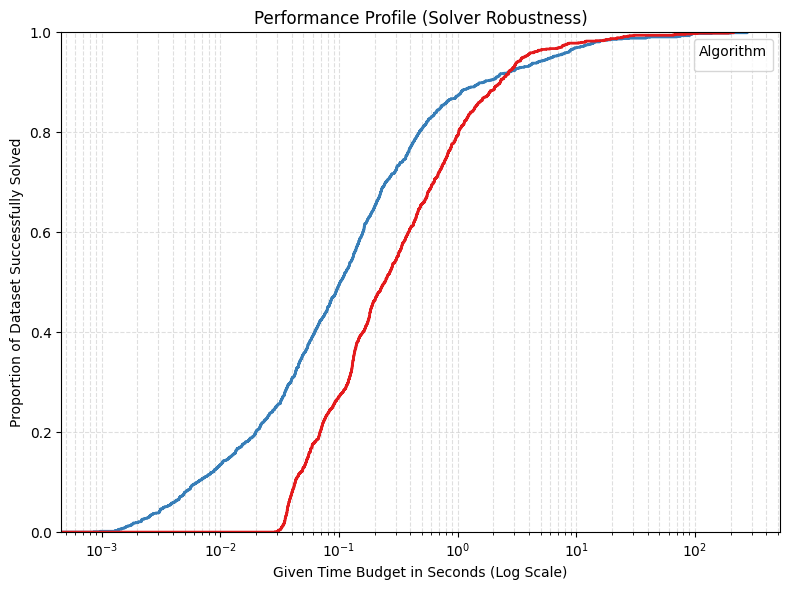

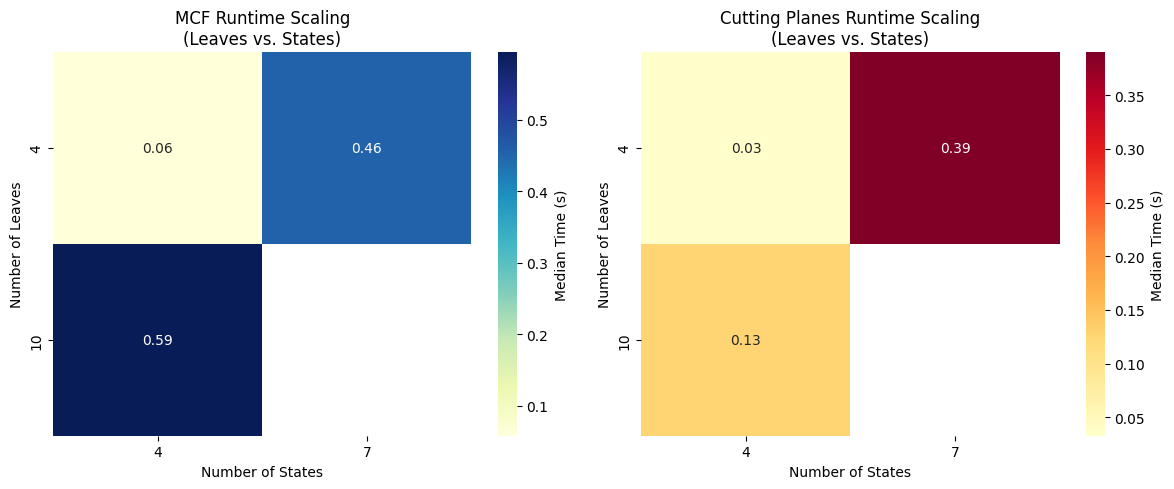

/var/folders/tj/bppvsjh16m990_1bbwvc05r80000gn/T/ipykernel_84028/2268009901.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


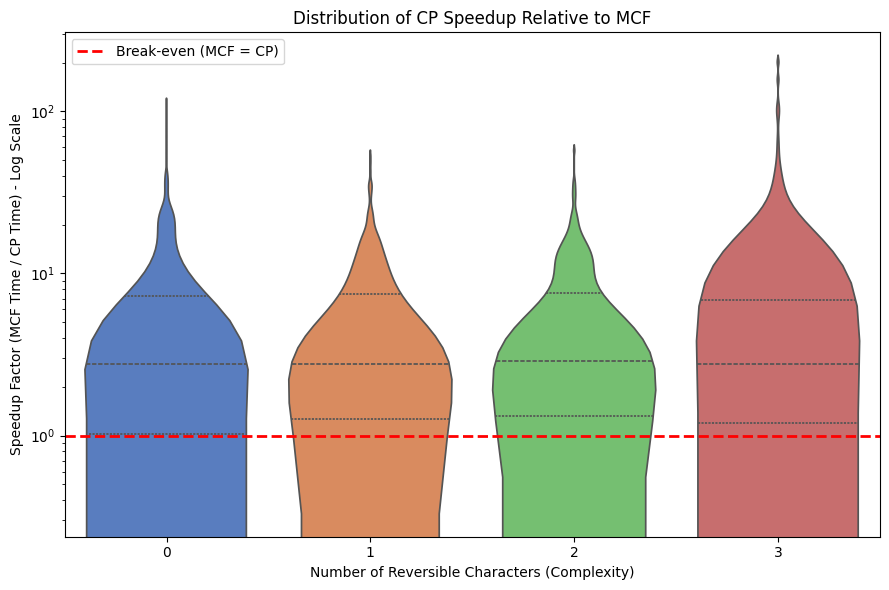

In [23]:


# Melt data for easy comparison plotting
df_melted = df.melt(
    id_vars=['id', 'n_leaves', 'n_states', 'num_reversible', 'score_match'], 
    value_vars=['time_original', 'time_cp'],
    var_name='Solver', 
    value_name='Runtime'
)
df_melted['Solver'] = df_melted['Solver'].map({'time_original': 'MCF (Original)', 'time_cp': 'Cutting Planes'})

# ==========================================
# PLOT 1: Performance Profile (ECDF Plot)
# (The "Gold Standard" for OR Algorithm Papers)
# ==========================================
plt.figure(figsize=(8, 6))

# An Empirical Cumulative Distribution Function (ECDF) shows the % of problems solved within a time budget
sns.ecdfplot(data=df_melted, x='Runtime', hue='Solver', palette='Set1', linewidth=2)

plt.xscale('log')
# plt.axvline(x=TIMEOUT_LIMIT, color='black', linestyle='--', alpha=0.5, label='Timeout Limit')
plt.xlabel("Given Time Budget in Seconds (Log Scale)")
plt.ylabel("Proportion of Dataset Successfully Solved")
plt.title("Performance Profile (Solver Robustness)")
plt.legend(title="Algorithm")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig("analysis_1_performance_profile.png", dpi=300)
plt.show()

# ==========================================
# PLOT 2: The Scaling Heatmap
# (Where exactly does the algorithm break?)
# ==========================================
plt.figure(figsize=(12, 5))

# Create pivot tables for median runtime: Leaves vs. States
pivot_mcf = df.pivot_table(index='n_leaves', columns='n_states', values='time_original', aggfunc='median')
pivot_cp = df.pivot_table(index='n_leaves', columns='n_states', values='time_cp', aggfunc='median')

# Subplot 1: MCF
plt.subplot(1, 2, 1)
sns.heatmap(pivot_mcf, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Median Time (s)'})
plt.title("MCF Runtime Scaling\n(Leaves vs. States)")
plt.xlabel("Number of States")
plt.ylabel("Number of Leaves")

# Subplot 2: Cutting Planes
plt.subplot(1, 2, 2)
sns.heatmap(pivot_cp, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Median Time (s)'})
plt.title("Cutting Planes Runtime Scaling\n(Leaves vs. States)")
plt.xlabel("Number of States")
plt.ylabel("Number of Leaves")

plt.tight_layout()
plt.savefig("analysis_2_scaling_heatmap.png", dpi=300)
plt.show()

# ==========================================
# PLOT 3: Speedup Factor Distribution (Violin Plot)
# (Visualizing the Variance)
# ==========================================
plt.figure(figsize=(9, 6))

# Filter to only valid, non-timeout runs for fair speedup comparison
df_valid = df[df['score_match'] == True]

# Violin plots show both the mean (box inside) and the density/variance (shape)
sns.violinplot(
    data=df_valid, 
    x='num_reversible', 
    y='speedup_factor', 
    palette='muted',
    inner='quartile'
)

# Add a horizontal line at 1.0 (The "Break-even" point)
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Break-even (MCF = CP)')

plt.yscale('log')
plt.xlabel("Number of Reversible Characters (Complexity)")
plt.ylabel("Speedup Factor (MCF Time / CP Time) - Log Scale")
plt.title("Distribution of CP Speedup Relative to MCF")
plt.legend()
plt.tight_layout()
plt.savefig("analysis_3_speedup_variance.png", dpi=300)
plt.show()